# Preprocessing

## 1. Consolidate individual datasets

### (a) Loading individual datasets

In [57]:
import pandas as pd
import os

# Check user is running this script from the 'engg2112' home directory.
current_folder = os.path.basename(os.getcwd())
if current_folder != "engg2112":
    print("Error: Please run this script from the 'engg2112' home directory.")
    exit()  # Stops the script immediately

FUEL_FILE = "datasets/fuel/NSW_E10_Full_Year_25_26.csv"
WEATHER_FILE = "datasets/weather/year_weather_dataset.csv"
OIL_FILE = "datasets/oil/daily oil price.xlsx"
TGP_FILE = "datasets/tgp/petrol_tgp.csv"
FX_FILE = "datasets/exchange/2023-current.xls"
COMPLETE_OUTPUT_FILE = "datasets/YEAR_COMPLETE_DATASET.csv"
MODEL_READY_OUTPUT_FILE = "datasets/MODEL_READY_DATASET.csv"

fuel_df = pd.read_csv(FUEL_FILE)
weather_df = pd.read_csv(WEATHER_FILE)
oil_df = pd.read_excel(OIL_FILE)
tgp_df = pd.read_csv(TGP_FILE)

# FX Data has unique formatting (metadata in top 11 rows)
fx_df_raw = pd.read_excel(FX_FILE, skiprows=1, nrows=0) # Get headers
fx_df = pd.read_excel(FX_FILE, skiprows=11, names=fx_df_raw.columns) # Get data

### (b) Standardising dates between datasets

In [58]:
# Convert Fuel Date - using mixed format and dayfirst for Australian/UK style dates
fuel_df['date'] = pd.to_datetime(
    fuel_df['PriceUpdatedDate'], 
    dayfirst=True, 
    format='mixed'
)

# Convert Weather Date
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Convert Oil Date
oil_df['date'] = pd.to_datetime(oil_df['date'])

# Convert TGP Date (First column is date)
tgp_date_col = tgp_df.columns[0]
tgp_df['date'] = pd.to_datetime(tgp_df[tgp_date_col])

# Convert FX Date (First column is date)
date_col = fx_df.columns[0]
fx_df['date'] = pd.to_datetime(fx_df[date_col], errors='coerce')

# fx dataset can be problematic; if datetime conversion fails, try Excel serial conversion
if fx_df['date'].isna().all():
    numeric_vals = pd.to_numeric(fx_df[date_col], errors='coerce')
    fx_df['date'] = pd.to_datetime(numeric_vals, unit='D', origin='1899-12-30')

# Drop rows that have no 'date' column (e.g., headers/footers) in this problematic csv
fx_df = fx_df.dropna(subset=['date'])

# Normalise all dates; so that time during day doesn't matter
df_list = [fuel_df, weather_df, oil_df, tgp_df, fx_df]
for df in df_list:
    df['date'] = df['date'].dt.normalize()

### (c) Rename and prepare columns for merging

In [59]:
oil_df = oil_df.rename(columns={'price': 'oil_price'})
tgp_df = tgp_df[['date', 'sydney_tgp']].rename(columns={'sydney_tgp': 'tgp_sydney'})

# Finding which column in fx_df.csv is the aud/usd column?
fx_col_candidates = [col for col in fx_df.columns if 'usd' in col.lower()]
if not fx_col_candidates:
    raise ValueError("Could not find AUD/USD column in FX dataset")

# There should just be one; either way take the first column as aud/usd
fx_col = fx_col_candidates[0]
fx_df = fx_df[['date', fx_col]].rename(columns={fx_col: 'aud_usd'})

# For adding a new column "region" into fuel_df
def assign_region(postcode):
    """Maps postcodes to your 6 specific weather regions"""
    try:
        p = int(postcode)
        if 2745 <= p <= 2780: return "Western_Sydney"
        elif (2170 <= p <= 2179) or (2560 <= p <= 2579): return "South_West_Sydney"
        elif (2250 <= p <= 2330) or (2280 <= p <= 2319): return "Hunter"
        elif 2500 <= p <= 2530: return "Wollongong"
        elif (2600 <= p <= 2620) or (2900 <= p <= 2914): return "Canberra"
        elif 2000 <= p <= 2199: return "Sydney_CBD"
        else: return "Regional"
    except:
        return "Regional"

# This is necessary so that can merge with weather_df, that only has region (not postcode)
fuel_df['Region'] = fuel_df['Postcode'].apply(assign_region)

### (d) Merging individual datasets 

In [60]:
# First merge fuel and weather df using the constructed 'Region' column
df_final = pd.merge(fuel_df, weather_df, on=['date', 'Region'], how='inner')

# Then, merge that with everything else using the standardised 'Date' column
df_final = pd.merge(df_final, oil_df, on='date', how='left')
df_final = pd.merge(df_final, tgp_df, on='date', how='left')
df_final = pd.merge(df_final, fx_df, on='date', how='left')

### (e) Filling weekend gaps in market data

In [61]:
# Market data (Oil, TGP, FX) is missing on weekends. 
# We fill forward so Saturday/Sunday uses Friday's price.
df_final = df_final.sort_values(by=['date', 'ServiceStationName'])
cols_to_fill = ['oil_price', 'tgp_sydney', 'aud_usd']
df_final[cols_to_fill] = df_final[cols_to_fill].ffill().bfill()

### (f) Saving complete dataset to output file

In [62]:
# Before saving, let's make all columns lowercase
df_final.columns = [col.lower() for col in df_final.columns]

# And then do the save
output_dir = os.path.dirname(COMPLETE_OUTPUT_FILE)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
df_final.to_csv(COMPLETE_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {COMPLETE_OUTPUT_FILE} is ready.")
print("-" * 80)

df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/YEAR_COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 160447 entries, 63 to 160351
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   servicestationname  160447 non-null  object        
 1   address             160447 non-null  object        
 2   suburb              160447 non-null  object        
 3   postcode            160447 non-null  int64         
 4   brand               160447 non-null  object        
 5   fuelcode            160447 non-null  object        
 6   priceupdateddate    160447 non-null  object        
 7   price               160447 non-null  float64       
 8   date                160447 non-null  datetime64[ns]
 9   region              160447 non-null  object  

## 2. Generate feature columns

### (a) Daily and weekly average features

In [63]:
# For each (postcode, date) pair, what is the average of all prices; rows that have (postcode, date)
daily_avg_df = df_final.groupby(['postcode', 'date'])['price'].mean().reset_index()

# This is a new df isn't it; daily_avg_df. Rename the price column within this to postcode_daily_avg
daily_avg_df.rename(columns={'price': 'postcode_daily_avg'}, inplace=True)

# Sort to ensure the timeline is chronological for the rolling calculation
daily_avg_df = daily_avg_df.sort_values(['postcode', 'date'])

# Make new column that is 7-day rolling average
# Note: What to do about the first 7 days of dataset? 
# This implements a simple solution, just do the best that can do, e.g.:
# - 1st day's average is just 1st day 
# - 2nd day's average is average of 1st and 2nd day
# - 3rd day's average is average of 1st, 2nd, and 3rd day
# - ...
# Alternatively, could also download the previous month's dataset,
# but I think that's a hassle; let's assume we only have access to 
# the datasets that are in the project repository.
daily_avg_df['postcode_rolling_7d'] = daily_avg_df.groupby('postcode')['postcode_daily_avg'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Merge new daily_avg_df with old df_final
df_final = df_final.merge(daily_avg_df, on=['postcode', 'date'], how='left')

### (b) Time lag features

In [64]:
# Making sure there is just one oil_price, tgp_sydney, and aud_usd for each date
lag_df = df_final.groupby('date')[['oil_price', 'tgp_sydney', 'aud_usd']].mean().reset_index()

# And sort by date so that can then calculate the time lag features
lag_df = lag_df.sort_values('date')
lag_df['oil_price_lag_1'] = lag_df['oil_price'].shift(1) # Yesterday
lag_df['oil_price_lag_7'] = lag_df['oil_price'].shift(7) # Last week
lag_df['tgp_sydney_lag_1'] = lag_df['tgp_sydney'].shift(1)
lag_df['tgp_sydney_lag_7'] = lag_df['tgp_sydney'].shift(7)
lag_df['aud_usd_lag_1'] = lag_df['aud_usd'].shift(1)
lag_df['aud_usd_lag_7'] = lag_df['aud_usd'].shift(7)

# Use fillna to fill in missing values (the first day and first week due to lag)
cols_to_fix = [
    'oil_price_lag_1', 'oil_price_lag_7', 
    'tgp_sydney_lag_1', 'tgp_sydney_lag_7', 
    'aud_usd_lag_1', 'aud_usd_lag_7'
]
lag_df[cols_to_fix] = lag_df[cols_to_fix].bfill()

# Take the subset ['date' + cols_to_fix] of lag_df, and merge with original
df_final = df_final.merge(lag_df[['date'] + cols_to_fix], on='date', how='left')

### (c) Day-of-week feature

In [65]:
# Save as a number from 0 to 6 inclusive
df_final['day_of_week'] = df_final['date'].dt.dayofweek

### (d) Target feature

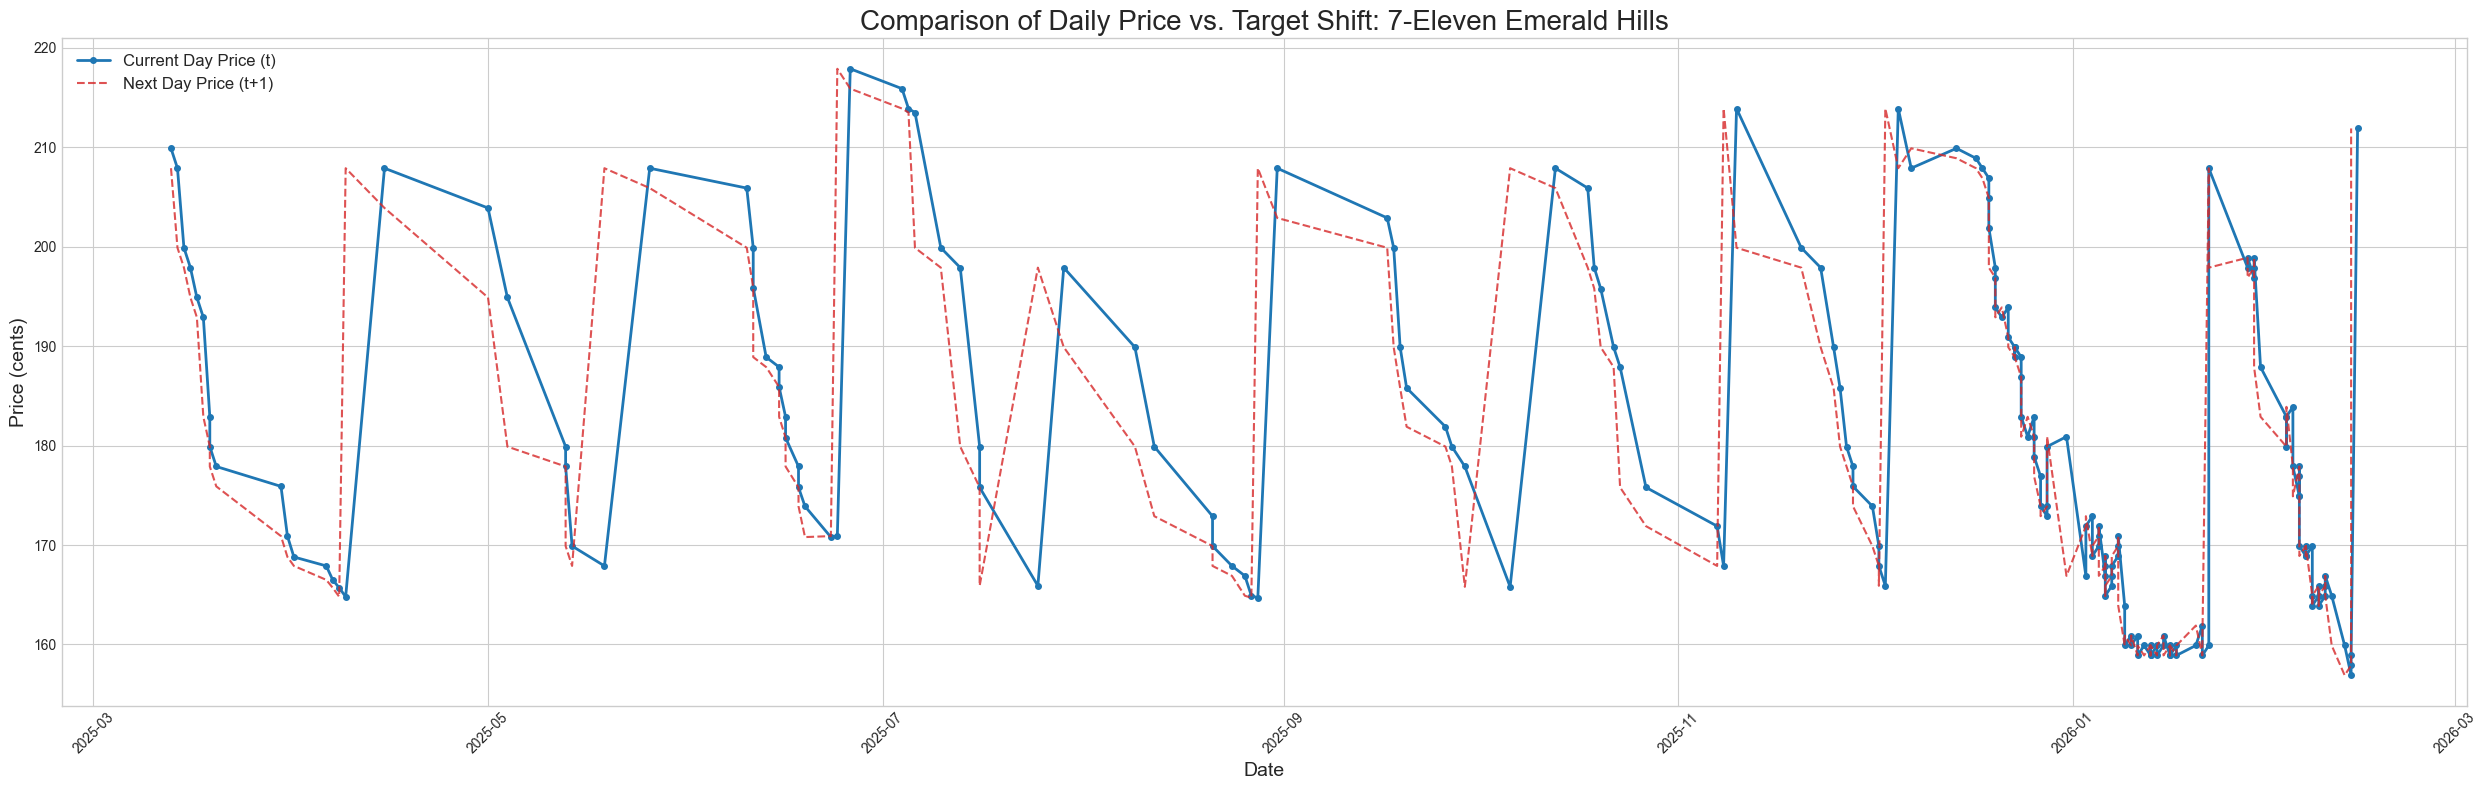

In [66]:
# This works only if every service station report E10 every single day; very unlikely!
df_final = df_final.sort_values(['servicestationname', 'date'])
df_final['target_next_day_price'] = df_final.groupby('servicestationname')['price'].shift(-1)



import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose a specific station to visualize (otherwise the lines will overlap)
# We'll take the first one found in the dataset
example_station = df_final['servicestationname'].unique()[42]
plot_data = df_final[df_final['servicestationname'] == example_station]

# 2. Set up the figure for a "Long" view
# figsize=(Width, Height) - 25 is very wide for long timelines
plt.figure(figsize=(25, 8))
sns.set_style("whitegrid")

# 3. Plot the Current Price (Input)
plt.plot(plot_data['date'], plot_data['price'], 
         label='Current Day Price (t)', 
         color='#1f77b4', 
         linewidth=2, 
         marker='o', 
         markersize=4)

# 4. Plot the Shifted Price (Target)
# Using a dashed red line to make the "shift" visually obvious
plt.plot(plot_data['date'], plot_data['target_next_day_price'], 
         label='Next Day Price (t+1)', 
         color='#d62728', 
         linestyle='--', 
         linewidth=1.5, 
         alpha=0.8)

# 5. Formatting for readability
plt.title(f'Comparison of Daily Price vs. Target Shift: {example_station}', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (cents)', fontsize=14)
plt.legend(fontsize=12, loc='upper left')

# Rotate the date labels so they fit on the long axis
plt.xticks(rotation=45)

# Adjust layout to make sure labels aren't cut off
plt.tight_layout()

plt.show()




# The solution? Only include consecutive rows where the days apart is exactly 1
# Note: This cuts A LOT of rows. 
df_final['target_date'] = df_final.groupby('servicestationname')['date'].shift(-1)
df_final['days_to_target'] = (df_final['target_date'] - df_final['date']).dt.days
df_final = df_final[df_final['days_to_target'] == 1]

# Drop the temp columns
df_final = df_final.drop(columns=['target_date', 'days_to_target'])

### (e) Saving model-ready dataset to output file

In [67]:
# Removing non-number and non-boolean columns; irrelevant to model training
cols_to_drop = [
    'servicestationname', 
    'address', 
    'suburb', 
    'region', 
    'date',
    'priceupdateddate',
    'brand',
    'fuelcode'
]
df_final = df_final.sort_values('date')
df_final = df_final.drop(columns=cols_to_drop)
df_final.to_csv(MODEL_READY_OUTPUT_FILE, index=False)

print("-" * 80)
print(f"SUCCESS: {MODEL_READY_OUTPUT_FILE} is ready.")
print("-" * 80)
df_final.info()

--------------------------------------------------------------------------------
SUCCESS: datasets/MODEL_READY_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 58554 entries, 59 to 160123
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   postcode               58554 non-null  int64  
 1   price                  58554 non-null  float64
 2   temp_max               58554 non-null  float64
 3   temp_min               58554 non-null  float64
 4   rainfall               58554 non-null  float64
 5   oil_price              58554 non-null  float64
 6   tgp_sydney             58554 non-null  float64
 7   aud_usd                58554 non-null  float64
 8   postcode_daily_avg     58554 non-null  float64
 9   postcode_rolling_7d    58554 non-null  float64
 10  oil_price_lag_1        58554 non-null  float64
 11 

# Training

## 3. Initial modelling and comparison with baseline

### (a) Load model-ready dataset and do train-test split

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

# Load model-ready dataset
try:
    df = pd.read_csv(MODEL_READY_OUTPUT_FILE)
except NameError:
    print(f"Error: MODEL_READY_OUTPUT_FILE does not exist yet")
    print("Please run the 'Preprocessing' code block of this notebook")
    raise SystemExit

# Separate Features (X) and Target (y)
X = df.drop(columns=['target_next_day_price'])
y = df['target_next_day_price']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### (b) Train using Random Forest and Linear Regressor

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

### (c) Compare the two models

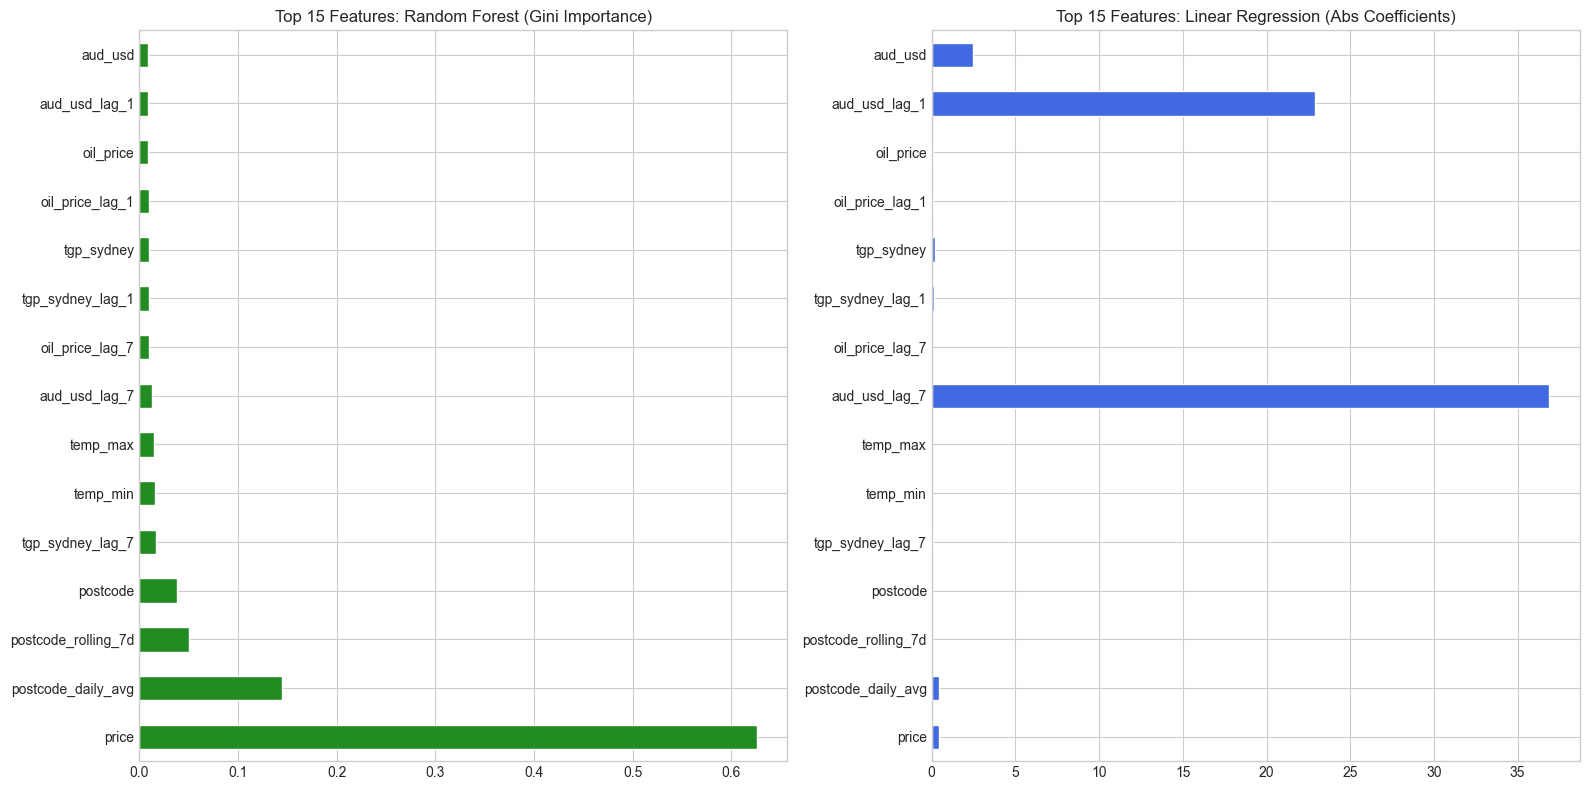

In [70]:
import pandas as pd
import numpy as np

# 1. Get RF Importances
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# 2. Get LR Coefficients (take absolute value to show magnitude of impact)
# We use absolute values because a large negative impact is still "important"
lr_importances = pd.Series(np.abs(lr_model.coef_), index=X_train.columns)

# Create a combined dataframe for plotting
importance_df = pd.DataFrame({
    'Random Forest': rf_importances,
    'Linear Regression': lr_importances
}).sort_values(by='Random Forest', ascending=False) # Sort by RF to see the difference

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

importance_df['Random Forest'].head(15).plot(kind='barh', ax=ax1, color='forestgreen')
ax1.set_title('Top 15 Features: Random Forest (Gini Importance)')

importance_df['Linear Regression'].head(15).plot(kind='barh', ax=ax2, color='royalblue')
ax2.set_title('Top 15 Features: Linear Regression (Abs Coefficients)')

plt.tight_layout()
plt.show()

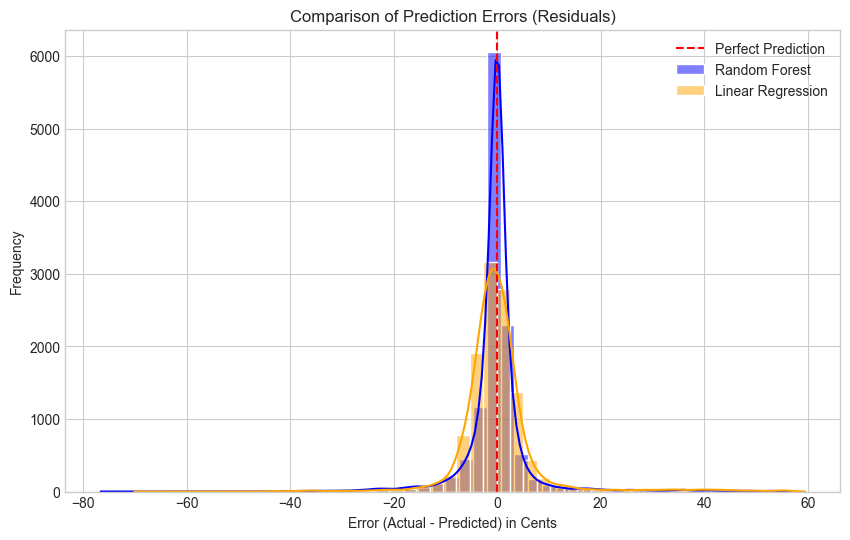

In [71]:
# Calculate residuals
rf_residuals = y_test - rf_predictions
lr_residuals = y_test - lr_predictions

plt.figure(figsize=(10, 6))

# Plot Random Forest Residuals
sns.histplot(rf_residuals, kde=True, bins=50, color='blue', label='Random Forest', alpha=0.5)

# Plot Linear Regression Residuals
sns.histplot(lr_residuals, kde=True, bins=50, color='orange', label='Linear Regression', alpha=0.5)

# Formatting
plt.title('Comparison of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction')
plt.legend() # This adds the labels to the plot
plt.show()

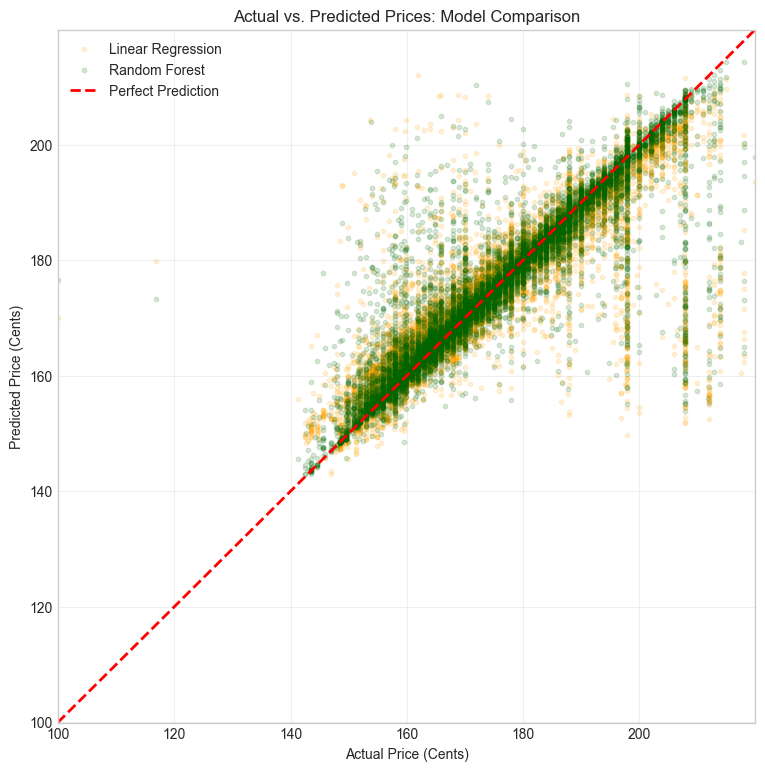

In [72]:
plt.figure(figsize=(9, 9))

# Plot Linear Regression
plt.scatter(y_test, lr_predictions, alpha=0.15, color='orange', label='Linear Regression', s=10)

# Plot Random Forest
plt.scatter(y_test, rf_predictions, alpha=0.15, color='darkgreen', label='Random Forest', s=10)

# Perfect Prediction Line
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Prices: Model Comparison')
plt.xlabel('Actual Price (Cents)')
plt.ylabel('Predicted Price (Cents)')
plt.xlim(line_range)
plt.ylim(line_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

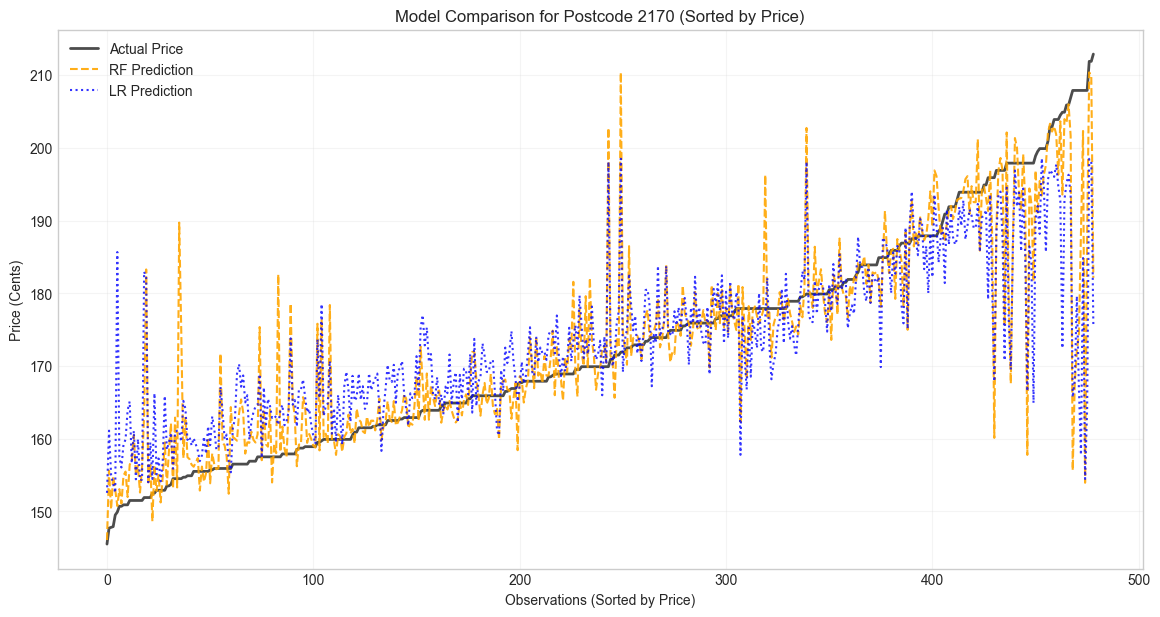

In [73]:
# 1. Add both predictions to your results dataframe
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['rf_pred'] = rf_predictions  # Using the variables from earlier
test_results['lr_pred'] = lr_predictions

# 2. Filter for your postcode
sample_postcode = test_results['postcode'].mode()[0]
sample_data = test_results[test_results['postcode'] == sample_postcode].copy()

# OPTIONAL: Sort by actual price to see how models handle low vs high values
sample_data = sample_data.sort_values(by='actual')

plt.figure(figsize=(14, 7))

# Plot Actuals
plt.plot(sample_data['actual'].values, label='Actual Price', color='black', lw=2, alpha=0.7)

# Plot Random Forest
plt.plot(sample_data['rf_pred'].values, label='RF Prediction', color='orange', linestyle='--', alpha=0.9)

# Plot Linear Regression
plt.plot(sample_data['lr_pred'].values, label='LR Prediction', color='blue', linestyle=':', alpha=0.8)

plt.title(f'Model Comparison for Postcode {sample_postcode} (Sorted by Price)')
plt.xlabel('Observations (Sorted by Price)')
plt.ylabel('Price (Cents)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()